<a href="https://colab.research.google.com/github/jaewoenlee/ML/blob/main/orgrad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

epoch = 0 MSE = 0.25
epoch = 100 MSE = 0.12847060139351069
epoch = 200 MSE = 0.10662980207395747
epoch = 300 MSE = 0.09041072258641052
epoch = 400 MSE = 0.07748467755466931
epoch = 500 MSE = 0.0671566826188961
epoch = 600 MSE = 0.058833946661615184
epoch = 700 MSE = 0.05204821079074233
epoch = 800 MSE = 0.04644934115081528
epoch = 900 MSE = 0.04177779851291386
w1 = 2.4044686117359277
w2 = 2.4044686117359277
b = -0.8319458946052253
0 0 0.3032337782729693 -> 0
0 1 0.8281429442107127 -> 1
1 0 0.8281429442107127 -> 1
1 1 0.9816028552977857 -> 1


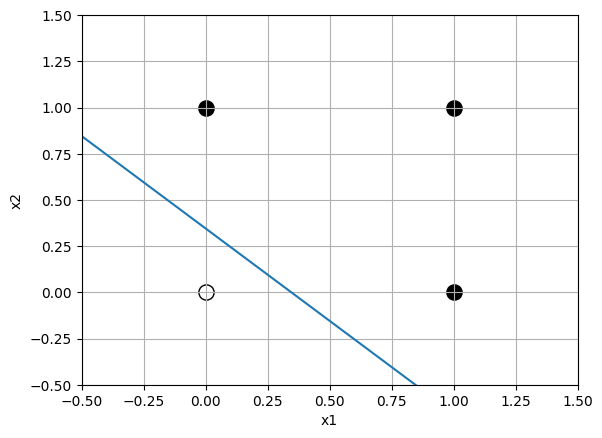

In [4]:
import math
import matplotlib.pyplot as plt
# OR gate input data and labels
X = [[0,0],[0,1],[1,0],[1,1]]
Y = [0,1,1,1]
# Initialize weights, bias, and learning rate
w1, w2, b = 0.0, 0.0, 0.0
learning_rate = 0.1
# Sigmoid activation function
def sigmoid(z):
    return 1/(1+math.exp(-z))
# Train using gradient descent with MSE
for epoch in range(1000):
    dw1 = dw2 = db = mse = 0.0
    for (x1,x2), y in zip(X,Y):
        y_pred = sigmoid(w1*x1+w2*x2+b)     # Forward propagation
        error = y_pred-y                    # Prediction error
        mse += error**2                     # Squared error
        d = 2*error*y_pred*(1-y_pred)       # Gradient through sigmoid
        dw1 += d*x1                         # Gradient for w1
        dw2 += d*x2                         # Gradient for w2
        db += d                             # Gradient for bias
    n = len(X)
    mse /= n
    dw1 /= n
    dw2 /= n
    db /= n
    w1 -= learning_rate*dw1                 # Update w1
    w2 -= learning_rate*dw2                 # Update w2
    b -= learning_rate*db                   # Update bias
    if epoch % 100 == 0:
        print("epoch =",epoch,"MSE =",mse)
# Print learned parameters
print("w1 =",w1)
print("w2 =",w2)
print("b =",b)
# Test the trained model
for x1,x2 in X:
    y_pred = sigmoid(w1*x1+w2*x2+b)
    result = 1 if y_pred >= 0.5 else 0
    print(x1,x2,y_pred,"->",result)
# Plot input data: y=1 black circle, y=0 white circle
for (x1,x2), y in zip(X,Y):
    if y == 1:
        plt.scatter(x1,x2,marker='o',s=120,facecolors='black',edgecolors='black')
    else:
        plt.scatter(x1,x2,marker='o',s=120,facecolors='white',edgecolors='black')
# Decision boundary: w1*x1 + w2*x2 + b = 0
x1_line = [-0.5,1.5]
x2_line = [-(w1*x+b)/w2 for x in x1_line]
plt.plot(x1_line,x2_line)
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-0.5,1.5)
plt.ylim(-0.5,1.5)
plt.grid(True)
plt.show()

In [2]:
# Test one full OR truth table using the learned w1, w2, b
print("x1 x2 | y | y_pred | result")
for (x1,x2), y in zip(X,Y):
    y_pred = sigmoid(w1*x1+w2*x2+b)
    result = 1 if y_pred >= 0.5 else 0
    print(x1, x2, "|", y, "|", round(y_pred,4), "|", result)

x1 x2 | y | y_pred | result
0 0 | 0 | 0.3032 | 0
0 1 | 1 | 0.8281 | 1
1 0 | 1 | 0.8281 | 1
1 1 | 1 | 0.9816 | 1
